In [7]:
import os
import sys
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, '../utils')

from utils import * 
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [8]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

nTrials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

params['N'] = nNodes = 10

In [9]:
P, ROI = modelP(nNodes, 10, "Low")

In [10]:
P.shape

(10, 10, 10)

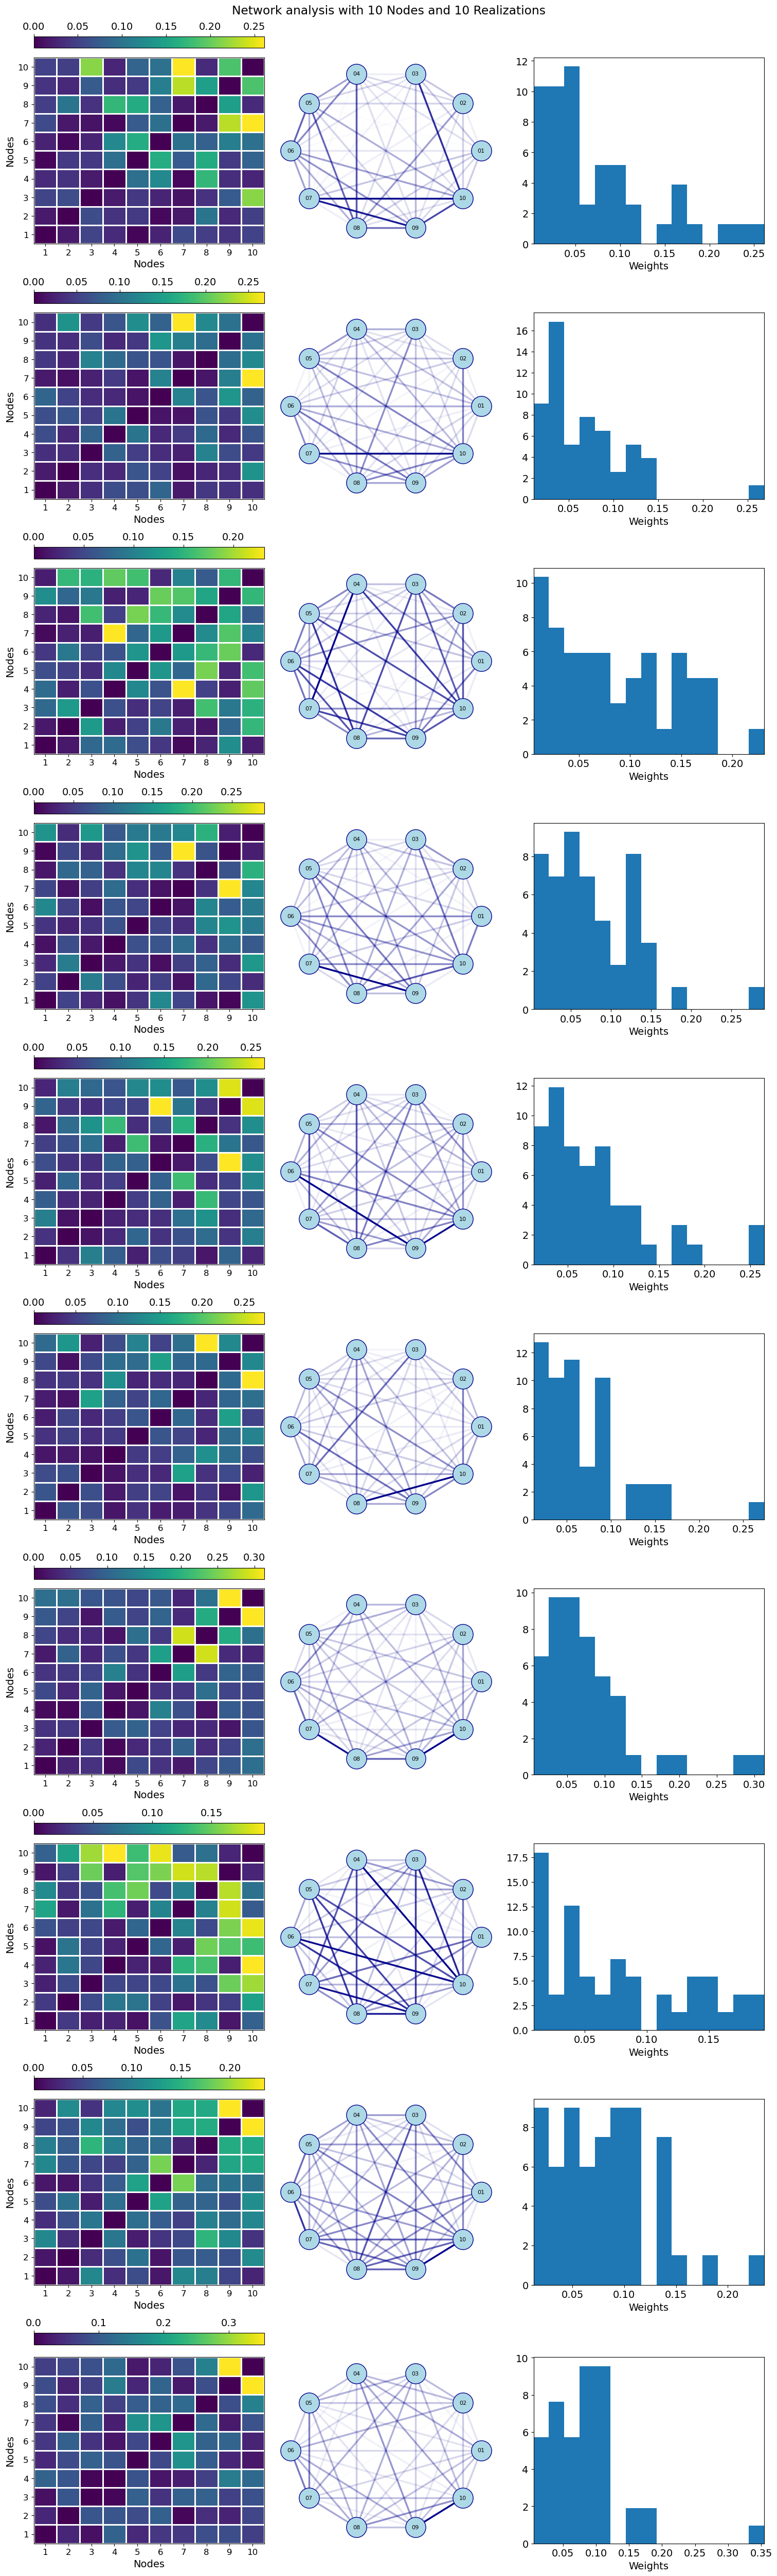

In [11]:
plotGraph(P, ifSave=False, save_dir='', figsize = (15, 5))

Text(0.5, 0.98, 'Network analysis with 10 Nodes and 10 Trials')

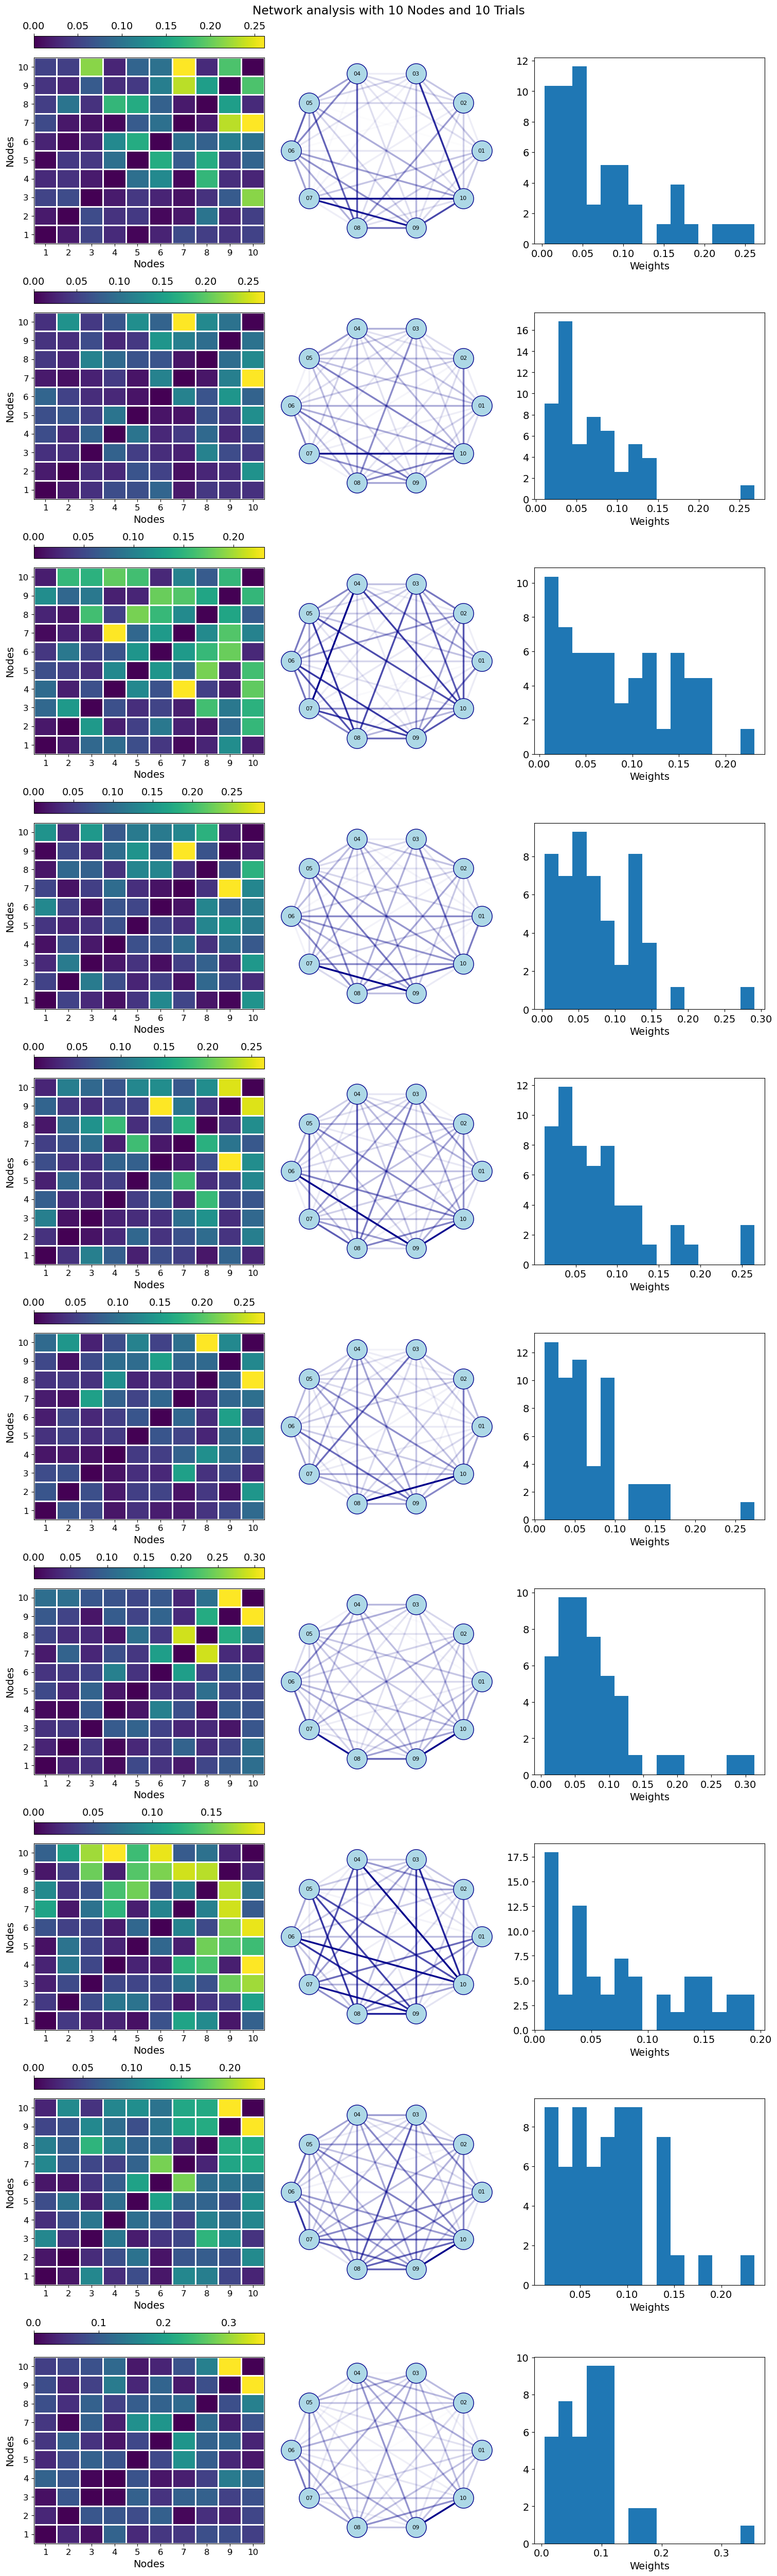

In [12]:
ROI_no = ROI

fig, axs = plt.subplots(nTrials, 3, figsize=(15, 50), gridspec_kw={'width_ratios':[1, 1, 1]}, layout='constrained')

for q in range(nTrials):
    pcol = axs[q, 0].pcolormesh(P[q], edgecolor='w')
    axs[q, 0].set_xticks(ROI_no + 0.5, ROI_no + 1, fontsize=12)
    axs[q, 0].set_yticks(ROI_no + 0.5, ROI_no + 1, fontsize=12)
    axs[q, 0].set_ylabel("Nodes")
    axs[q, 0].set_xlabel("Nodes")
    fig.colorbar(pcol, ax = axs[q, 0], location='top')


    G = nx.from_numpy_array(P[q], parallel_edges=False)
    pos = nx.circular_layout(G) 
    nx.draw_networkx_nodes(G, pos, ax=axs[q, 1], node_color='lightblue', edgecolors='darkblue', node_size=800)

    # Adding labels to the nodes
    labels = {}
    for n in range(nNodes):
        labels[n] = f"{ROI_no[n] + 1:02d}"

    nx.draw_networkx_labels(G, pos, labels, ax=axs[q, 1], font_size=8)

    all_weights = []
    #4 a. Iterate through the graph nodes to gather all the weights
    for (node1, node2, data) in G.edges(data = True):
        all_weights.append(data['weight']) 

    #4 b. Get unique weights
    unique_weights = list(set(all_weights))
    maxWeight = np.max(unique_weights)

    #4 c. Plot the edges - one by one!
    for weight in unique_weights:
        #4 d. Form a filtered list with just the weight you want to draw
        weighted_edges = [(node1,node2) for (node1,node2,edge_attr) in G.edges(data=True) if edge_attr['weight']==weight]
        nx.draw_networkx_edges(G, pos, ax=axs[q, 1], edge_color='darkblue', alpha = weight / maxWeight, edgelist = weighted_edges, width = 2.5)

    #Plot the graph
    axs[q, 1].axis('off')

    hist = axs[q, 2].hist(P[q][np.triu_indices(nNodes, k=1)], bins=15, density=True)
    axs[q, 2].set_xlabel("Weights")

fig.suptitle(f"Network analysis with {nNodes:02d} Nodes and {nTrials:02d} Trials")